## Overview 

The aim of this notebook is to manually test a new take on transient PL. The goal is to run a transient simulation that switches from SC to OC once the system has reached a SC steady-state. I used the basic device from the website and will now create a tVG file manually to run the experiment

In [3]:
import os, sys
import numpy as np
import typing 
from numbers import Number
from dataclasses import dataclass
import pandas as pd
import matplotlib.pyplot as plt
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../..')
    import pySIMsalabim as sim

In [4]:
# Load results 
session_path = os.path.join("../../", "SIMsalabim/ZimT")
data = pd.read_csv(os.path.join(session_path, "tj.dat"), sep=r"\s+")

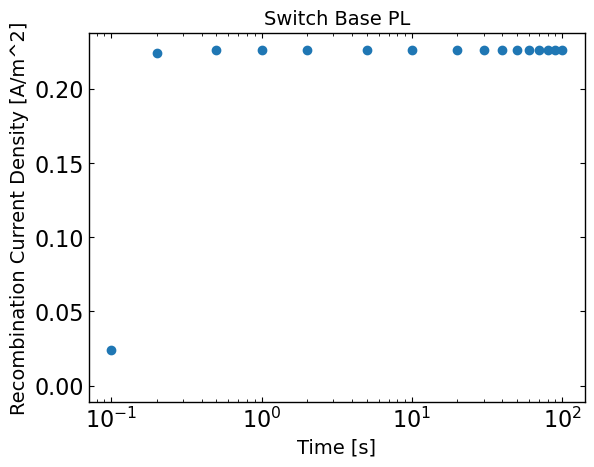

In [5]:
plt.scatter(data["t"], data["JdirL2"])
plt.xscale('log')
plt.xlabel("Time [s]")
plt.ylabel("Recombination Current Density [A/m^2]")
plt.title("Switch Base PL")
plt.show()

Now that we've tested to make sure this works, I think I may try varing some parameters to see if I can get a kick.

## Multiple runs for varying Ion Densities

For all the runs below, both mu_anion and mu_cation = 1E-11 but with varying densities

In [6]:
N_ion = ["3E21", "4E21", "5E21", "6E21", "7E21", "8E21", "9E21", "1E22", "2E22", "3E22"]

In [7]:
float(N_ion[0])

3e+21

In [19]:
@dataclass
class ZimtRun:
    N_anion: Number
    N_cation: Number
    mu_anion: Number
    mu_cation: Number
    tj_data: pd.DataFrame

In [20]:
zimt_runs = []

for ion_density in N_ion:
    file_name = f"tj_N_ion_{ion_density}.dat"
    file_data = pd.read_csv(os.path.join(session_path, file_name), sep=r"\s+")
    zimt_run = ZimtRun(N_anion=float(ion_density), N_cation=float(ion_density), tj_data=file_data, mu_anion=1E-11, mu_cation=1E-11)
    zimt_runs.append(zimt_run)

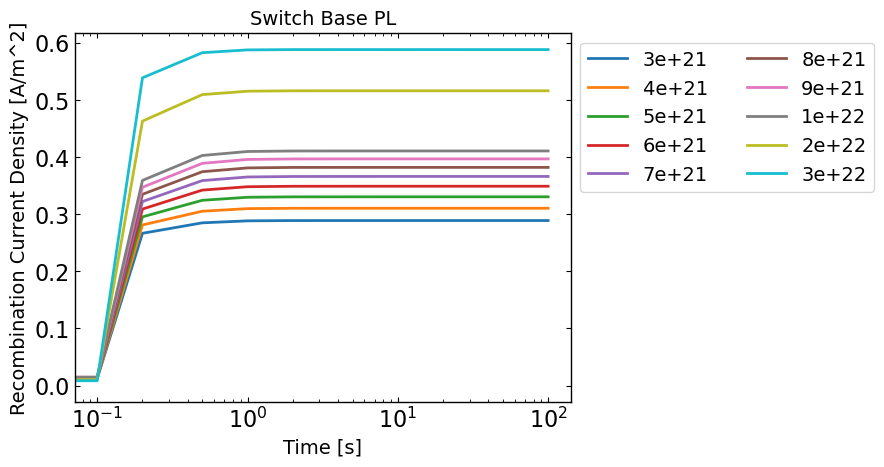

In [ ]:
for zimt_run in zimt_runs:
    plt.plot(zimt_run.tj_data["t"], zimt_run.tj_data["JdirL2"], label=zimt_run.N_anion)

plt.xscale('log')
plt.xlabel("Time [s]")
plt.ylabel("Recombination Current Density [A/m^2]")
plt.title("Switch Base PL for varying ionic density")
plt.legend(bbox_to_anchor=(1,1),ncols=2)
plt.show()

There still doesn't seem to be anything in the way of a kick-back here. Jan Anton has suggested decreasing the ion mobilites to see if this results in a more noticable overshoot.

## Testing the effects of decreasing ion mobility
For this test:
- Mobilities will be kept equal for both anions and cations at 1E22
- I will vary mobilities from 1E-11 to 1E-15.

I would also like to increase the resolution in time immediately after the switch to OC, which I will do here.

In [73]:
tVG_filename = 'tVG_high_res.dat'

# Script to write a tVG file
tVG_header = 't Vext G_frac\n'
tVG_short_circuit_steady_state = '0 0 1\n'

# To reduce the internal displacement current, we add an intermidiate transition step to OC
tVG_transition_step = '0.1 1 1\n'

# From this point, we want logarithmically spaced timesteps
tVG_oc_steady_state = ''
for time in np.geomspace(2E-1, 1E2, 50):
    tVG_oc_steady_state += f'{time} oc 1\n'
    
tVG_file_string = tVG_header + tVG_short_circuit_steady_state + tVG_transition_step + tVG_oc_steady_state
    
# Write the tVG lines to the tVG file
with open(os.path.join(session_path,tVG_filename), 'w') as file:
    file.write(tVG_file_string)

In [74]:
mu_ions = [1E-11, 1E-12, 1E-13, 1E-14, 1E-15]

In [75]:
# Read in data 
zimt_runs = []

for ion_mobility in mu_ions:
    file_name = f"tj_mu_ions_{ion_mobility}.dat"
    file_data = pd.read_csv(os.path.join(session_path, file_name), sep=r"\s+")
    zimt_run = ZimtRun(N_anion=1E22, N_cation=1E22, tj_data=file_data, mu_anion=float(ion_mobility), mu_cation=float(ion_mobility))
    zimt_runs.append(zimt_run)

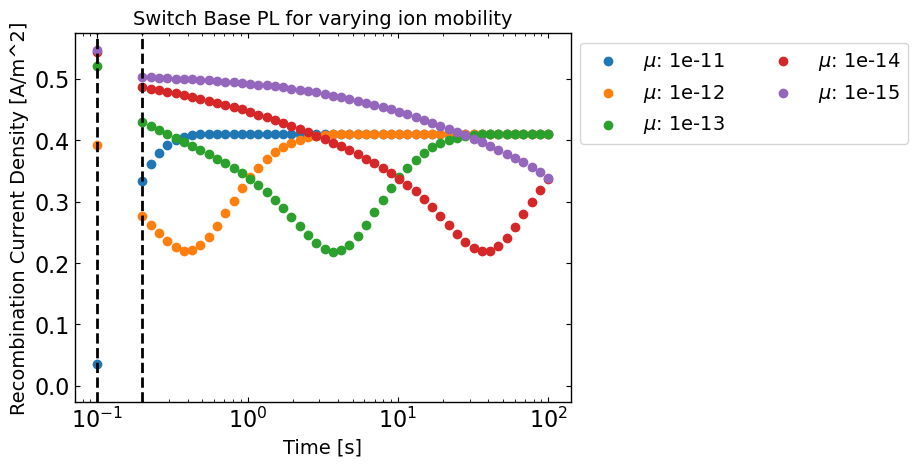

In [81]:
for zimt_run in zimt_runs:
    label = f"$\\mu$: {zimt_run.mu_anion}"
    plt.scatter(zimt_run.tj_data["t"], zimt_run.tj_data["JdirL2"], label=label)

plt.xscale('log')
plt.axvline(0.1, linestyle='--', color='black') # Mark the initial voltage step
plt.axvline(0.2, linestyle='--', color='black') # Mark the completion of the transition to Voc
plt.xlabel("Time [s]")
plt.ylabel("Recombination Current Density [A/m^2]")
plt.title("Switch Base PL for varying ion mobility")
plt.legend(bbox_to_anchor=(1,1),ncols=2)
plt.show()

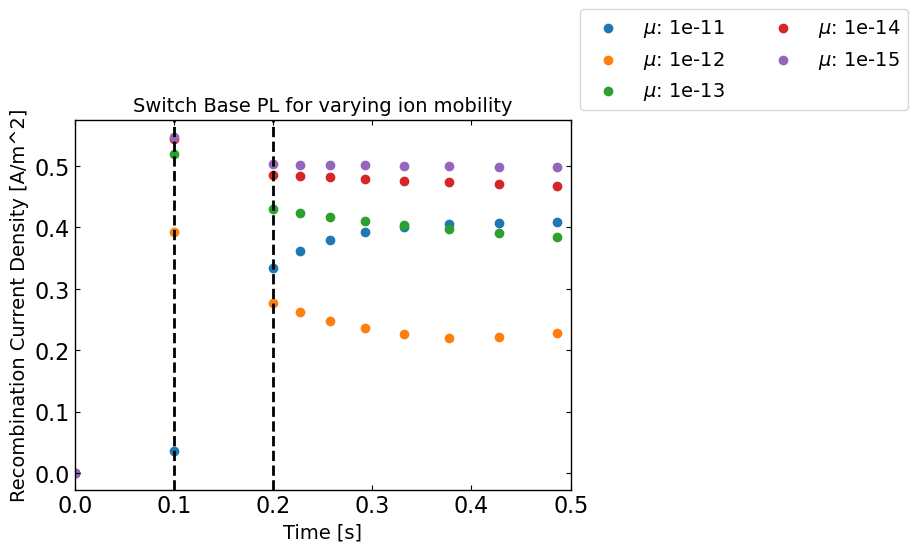

In [79]:
for zimt_run in zimt_runs:
    label = f"$\\mu$: {zimt_run.mu_anion}"
    plt.scatter(zimt_run.tj_data["t"], zimt_run.tj_data["JdirL2"], label=label)

plt.axvline(0.1, linestyle='--', color='black') # Mark the initial voltage step
plt.axvline(0.2, linestyle='--', color='black') # Mark the completion of the transition to Voc
plt.xlabel("Time [s]")
plt.ylabel("Recombination Current Density [A/m^2]")
plt.title("Switch Base PL for varying ion mobility")
plt.legend(bbox_to_anchor=(1,1),ncols=2)
plt.xlim((0, 0.5))
plt.show()

Here we see several notable effects:
1. Decreasing ion mobility seems to increase the SC steady state radiative recombination, even to being greater the OC radiative recombination
2. Decreasing ion mobility results in a radiative recombination 'trough' that occurs at later times, suggesting mobile response from ions does play a key role in this process.

- Ordinarily, I would expect radiative recombination to be greater at open circuit than at short circuit. Why does that depend on ion mobility? 

I want to check if there's some easy relationship we can draw between the mobility and the peak location and the mobility and the starting recombination.

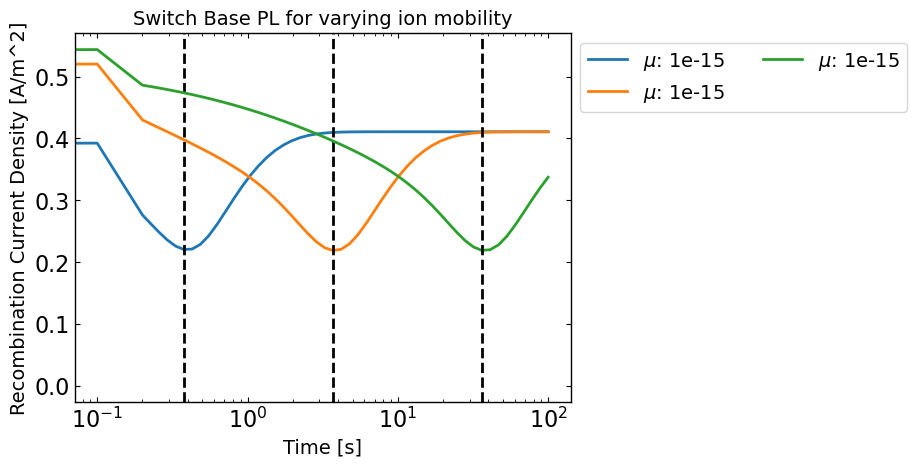

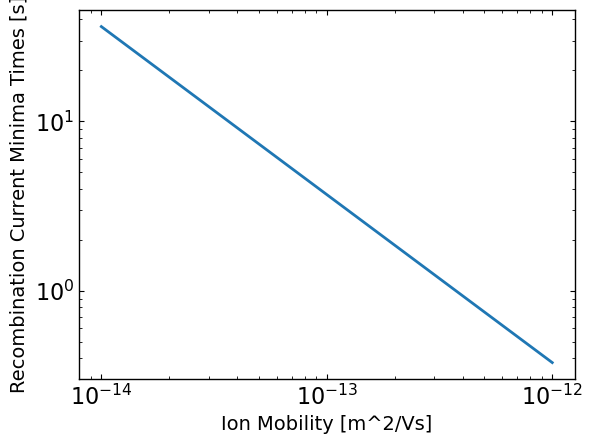

In [ ]:
# Try to get some peak times for the different decay processes 
from scipy.signal import find_peaks

recombination_current_trough_indexes = []

for run in zimt_runs[1:4]:
    peaks = find_peaks(1/run.tj_data["JdirL2"].values, height=0.1)[0]
    recombination_current_trough_indexes.append(peaks[0])
        
    label = f"$\\mu$: {zimt_run.mu_anion}"
    plt.plot(run.tj_data['t'],run.tj_data['JdirL2'], label=label)
    plt.axvline(run.tj_data['t'][peaks[0]], linestyle='--', color='black')
    
plt.xscale('log')
plt.xlabel("Time [s]")
plt.ylabel("Recombination Current Density [A/m^2]")
plt.title("Switch Base PL for varying ion mobility")
plt.legend(bbox_to_anchor=(1,1),ncols=2)
plt.show()

# Plot peak times against mobility
ion_mobility = [run.mu_anion for run in zimt_runs[1:4]]
recombination_current_trough_times = [run.tj_data['t'][index] for index in recombination_current_trough_indexes]

plt.plot(ion_mobility, recombination_current_trough_times)
plt.xlabel("Ion Mobility [m^2/Vs]")
plt.ylabel("Recombination Current Minima Times [s]")
plt.xscale("log")
plt.yscale("log")
plt.title("")
plt.show()

Working explanation of this phenomina:
1. In SC steady state, we expect ionic screening to be maximal in the perovskite close to the interface layers
2. When we switch to OS, these interface layers inhibit the injection of carriers into the transport layers as they screen the built in field, leading to an overshoot in PL.
3. As the ions diffuse away from eachother (which is where mobility comes in), the built in potential increases, improving carrier separation and injection into the transport layers. This separation causes the drop in PL.
4. As time goes on, carrier injection into the transport layers begins to inhibit further seperation, leading to the later rise in PL until steady state is reached.